# Clasificación: Detección de Fatiga Muscular en Ciclismo 

## Paso 1: Análisis Preliminar del Problema

In [1]:
from datasets import load_dataset
import numpy as np
import pandas as pd

ds = load_dataset("YominE/Muscle_Fatigue_Cycling")
df = ds["train"].to_pandas()

fs = 1000
window_size = fs # 1 segundo = 1000 muestras

channels = ['Right Rectus femoris', 'Left Gluteus maximus',
       'Left Gastrocnemius medialis', 'Left Semitendinosus',
       'Left Biceps femoris caput longus', 'Right Vastus medialis',
       'Right Tibialis anterior', 'Left Gastrocnemius lateralis']

# Calcular cuántas ventanas completas caben
n_windows = len(df) // window_size

df = df.replace(2 , 1)

print(df.head())
print(f"Total de muestras: {len(df)}")
print(f"Ventanas de 1 segundo: {n_windows}")

/home/alejo/Universidad/IA/Taller2/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    Time  Right Rectus femoris  Left Gluteus maximus  \
0  0.000             -0.000264             -0.000015   
1  0.001             -0.001002             -0.000045   
2  0.002             -0.002173             -0.000034   
3  0.003             -0.002676              0.000185   
4  0.004             -0.000844              0.000785   

   Left Gastrocnemius medialis  Left Semitendinosus  \
0                     0.000344             0.000108   
1                     0.001342             0.000429   
2                     0.002944             0.001133   
3                     0.003504             0.002319   
4                     0.000426             0.003950   

   Left Biceps femoris caput longus  Right Vastus medialis  \
0                          0.000182               0.000401   
1                          0.000712               0.002234   
2                          0.001692               0.007634   
3                          0.002820               0.017656   
4                     

Observando la cabecera del DataFrame, se puede apreciar que contiene 10 columnas. Ocho de ellas corresponden a las mediciones de las señales EMG provenientes de ocho músculos del pie dominante de la persona que realiza la prueba de ciclismo. Estas ocho columnas son variables numéricas continuas.
Por otro lado, se encuentra la columna de tiempo, la cual también corresponde a una variable numérica continua.
Finalmente, está la columna target, que, según la descripción del dataset, presenta un carácter ordinal, ya que refleja una progresión en el nivel de fatiga: 0 indica ausencia de fatiga, 1 representa una transición hacia la fatiga y 2 corresponde a un estado de fatiga. Pero, después del preprocesamiento se convierte en una variable categórica binaria, donde 0 representa la condición normal y 1 el desgaste muscular.

## Paso 2: Extracción de Características (Feature Engineering)

In [66]:
from scipy.signal import welch

def extraer_caracteristicas(ventana, fs=1000):
    """Extrae características de tiempo y frecuencia de una ventana 1D."""
    # --- Dominio del tiempo ---
    rms     = np.sqrt(np.mean(ventana**2)) # La energía o fuerza promedio de la señal
    varianza = np.var(ventana) # Qué tan dispersos están los valores
    zcr     = np.sum(np.diff(np.sign(ventana)) != 0) # Cuántas veces la señal cruza el cero
    mav     = np.mean(np.abs(ventana)) # Promedio del valor absoluto

    # --- Dominio de la frecuencia ---
    freqs, psd = welch(ventana, fs=fs) 
    pot_acum   = np.cumsum(psd) 
    idx_median = np.searchsorted(pot_acum, pot_acum[-1] / 2)
    frec_mediana = freqs[idx_median] # La frecuencia que divide la potencia espectral en dos mitades iguales

    pot_total  = np.sum(psd) # Energía total de la señal en frecuencia

    frec_media = np.sum(freqs * psd) / np.sum(psd) # Promedio ponderado de las frecuencias	

    return [rms, varianza, zcr, mav, pot_total, frec_media, frec_mediana]

# Construir el nuevo dataset
filas = []

for i in range(n_windows):
    inicio = i * window_size
    fin = inicio + window_size

    ventana_df = df.iloc[inicio:fin] # Todas las filas que estan entre el inicio y el final

    fila = {}

    for canal in channels:
        ventana = ventana_df[canal].values
        feats   = extraer_caracteristicas(ventana, fs=fs)

        nombres = ['rms', 'var', 'zcr', 'mav', 'pot', 'f_media', 'f_mediana']
        for nombre, valor in zip(nombres, feats):
            fila[f'{canal}_{nombre}'] = valor

    # El target de la ventana es el más frecuente en esas 1000 muestras
    fila['target'] = ventana_df['Target'].mode()[0]

    filas.append(fila)

nuevo_df = pd.DataFrame(filas)


### Características seleccionadas

Se seleccionaron las 7 características propuestas en el documento-tutorial del profesor Yomin para cada músculo del dataset.

Esta decisión fue tomada considerando que, al aplicar una agregación por ventanas de un segundo en lugar de trabajar con las mediciones por milisegundo, el dataset pasó de aproximadamente 500.000 filas a 500. Ante esta reducción tan significativa en el número de observaciones, se consideró fundamental extraer la mayor cantidad de información representativa posible por músculo y por ventana.

Cada característica fue seleccionada porque captura un aspecto distinto de la señal: la potencia promedio (RMS, MAV), la dispersión de los valores (varianza), el comportamiento oscilatorio (Zero Crossing Rate) y la distribución de energía en el dominio de la frecuencia (frecuencia media, frecuencia mediana y potencia espectral total).

Contar con estas métricas complementarias garantiza que, aunque el número de filas se haya reducido drásticamente, la esencia de la señal muscular quede preservada a través de sus características más relevantes — asegurando que los modelos dispongan de información suficiente y representativa para entrenarse de manera adecuada.

## Paso 3: EDA

In [ ]:
import matplotlib.pyplot as plt
lista_de_features = nuevo_df.columns.to_list()

todos_los_musculos = lista_de_features[0:56]
# Obetener cada musculo con sus 8 caracteristicas
primer_musculo = lista_de_features[0:7]
segundo_musculo = lista_de_features[7:14]
tercer_musculo = lista_de_features[14:21]
cuarto_musculo = lista_de_features[21:28]
quinto_musculo = lista_de_features[28:35]
sexto_musculo = lista_de_features[35:42]
septimo_musculo = lista_de_features[42:49]
octavo_musculo = lista_de_features[49:56]


56


### Distribuciones de variables y estadísticos descriptivos

In [ ]:
def interpretar_estadisticas(serie, nombre):
    desc = serie.describe()
    media = desc['mean']
    mediana = serie.median()
    std = desc['std']
    minimo = desc['min']
    maximo = desc['max']
    nulos = serie.isnull().sum()
    pct_nulos = (nulos / len(serie)) * 100
    skewness = serie.skew()
    kurtosis = serie.kurtosis()
    cv = (std / media * 100) if media != 0 else float('inf')  # Coeficiente de variación

    print(f"\n{'='*60}")
    print(f"  ESTADÍSTICA DESCRIPTIVA: {nombre}")
    print(f"{'='*60}")
    display(desc)

    print(f"\n📋 CONSIDERACIONES:")

    # Nulos
    if pct_nulos == 0:
        print(f"  ✅ Sin valores nulos.")
    elif pct_nulos <= 5:
        print(f"  ⚠️  Nulos leves: {nulos} ({pct_nulos:.1f}%) — considera imputar con media/mediana.")
    elif pct_nulos <= 30:
        print(f"  🔶 Nulos moderados: {nulos} ({pct_nulos:.1f}%) — evalúa imputación avanzada (KNN, MICE).")
    else:
        print(f"  🔴 Nulos críticos: {nulos} ({pct_nulos:.1f}%) — considera eliminar la feature.")

    # Sesgo (Skewness)
    if abs(skewness) < 0.5:
        print(f"  ✅ Distribución simétrica (skewness={skewness:.2f}) — sin transformación necesaria.")
    elif abs(skewness) < 1:
        print(f"  ⚠️  Sesgo moderado (skewness={skewness:.2f}) — puede funcionar bien, monitorea el modelo.")
    else:
        direccion = "positivo (cola derecha)" if skewness > 0 else "negativo (cola izquierda)"
        print(f"  🔶 Sesgo fuerte {direccion} (skewness={skewness:.2f}) — considera transformación log/sqrt/Box-Cox.")

    # Curtosis
    if abs(kurtosis) < 1:
        print(f"  ✅ Curtosis normal (kurtosis={kurtosis:.2f}) — colas ligeras, pocos outliers extremos.")
    elif kurtosis >= 1:
        print(f"  ⚠️  Curtosis alta (kurtosis={kurtosis:.2f}) — colas pesadas, probables outliers significativos.")
    else:
        print(f"  ℹ️  Curtosis negativa (kurtosis={kurtosis:.2f}) — distribución aplanada, datos muy dispersos.")

    # Media vs Mediana
    if media != 0:
        diff_pct = abs((media - mediana) / media) * 100
        if diff_pct < 5:
            print(f"  ✅ Media ({media:.2f}) ≈ Mediana ({mediana:.2f}) — distribución balanceada.")
        elif diff_pct < 20:
            print(f"  ⚠️  Media ({media:.2f}) y Mediana ({mediana:.2f}) difieren ({diff_pct:.1f}%) — sesgo o outliers presentes.")
        else:
            print(f"  🔶 Gran diferencia Media ({media:.2f}) vs Mediana ({mediana:.2f}) ({diff_pct:.1f}%) — outliers distorsionan la media.")

    # Variabilidad (Coeficiente de variación)
    if cv < 15:
        print(f"  ⚠️  Baja variabilidad (CV={cv:.1f}%) — la feature puede aportar poca información al modelo.")
    elif cv <= 100:
        print(f"  ✅ Variabilidad adecuada (CV={cv:.1f}%) — la feature tiene dispersión útil.")
    else:
        print(f"  🔶 Variabilidad muy alta (CV={cv:.1f}%) — revisa outliers o considera normalización.")

    # Rango
    rango = maximo - minimo
    print(f"  ℹ️  Rango: [{minimo:.2f} — {maximo:.2f}] (amplitud={rango:.2f})")
    if rango == 0:
        print(f"  🔴 Rango = 0: feature constante, no aporta nada — elimínala.")

La estadistica descriptiva de la caracteristica Right Rectus femoris_rms

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_rms


count    3002.000000
mean        0.035700
std         0.024379
min         0.002970
25%         0.021569
50%         0.029745
75%         0.042171
max         0.190683
Name: Right Rectus femoris_rms, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  🔶 Sesgo fuerte positivo (cola derecha) (skewness=2.78) — considera transformación log/sqrt/Box-Cox.
  ⚠️  Curtosis alta (kurtosis=10.15) — colas pesadas, probables outliers significativos.
  ⚠️  Media (0.04) y Mediana (0.03) difieren (16.7%) — sesgo o outliers presentes.
  ✅ Variabilidad adecuada (CV=68.3%) — la feature tiene dispersión útil.
  ℹ️  Rango: [0.00 — 0.19] (amplitud=0.19)


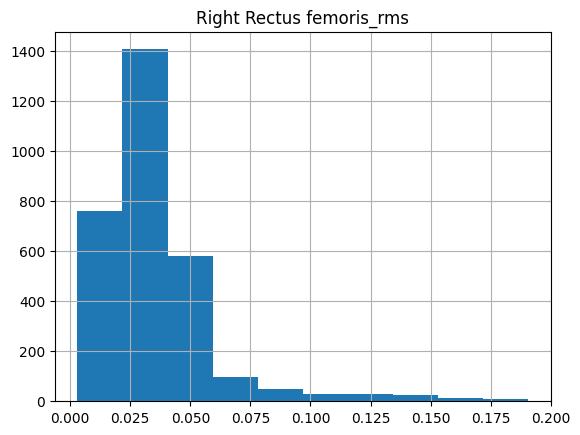

La estadistica descriptiva de la caracteristica Right Rectus femoris_var

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_var


count    3002.000000
mean        0.001869
std         0.003613
min         0.000009
25%         0.000465
50%         0.000885
75%         0.001778
max         0.036360
Name: Right Rectus femoris_var, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  🔶 Sesgo fuerte positivo (cola derecha) (skewness=5.12) — considera transformación log/sqrt/Box-Cox.
  ⚠️  Curtosis alta (kurtosis=30.59) — colas pesadas, probables outliers significativos.
  🔶 Gran diferencia Media (0.00) vs Mediana (0.00) (52.7%) — outliers distorsionan la media.
  🔶 Variabilidad muy alta (CV=193.4%) — revisa outliers o considera normalización.
  ℹ️  Rango: [0.00 — 0.04] (amplitud=0.04)


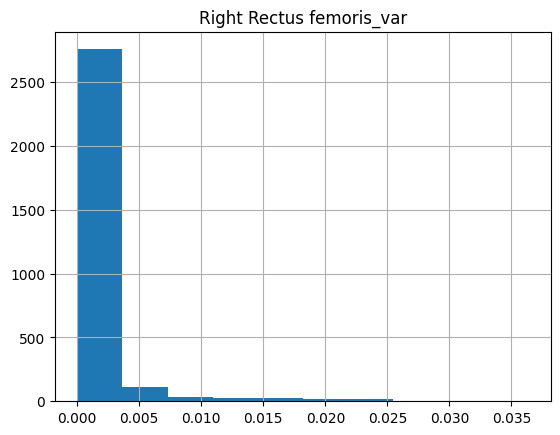

La estadistica descriptiva de la caracteristica Right Rectus femoris_zcr

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_zcr


count    3002.000000
mean      108.874084
std        13.094489
min        63.000000
25%       100.000000
50%       109.000000
75%       118.000000
max       155.000000
Name: Right Rectus femoris_zcr, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  ✅ Distribución simétrica (skewness=0.13) — sin transformación necesaria.
  ✅ Curtosis normal (kurtosis=-0.01) — colas ligeras, pocos outliers extremos.
  ✅ Media (108.87) ≈ Mediana (109.00) — distribución balanceada.
  ⚠️  Baja variabilidad (CV=12.0%) — la feature puede aportar poca información al modelo.
  ℹ️  Rango: [63.00 — 155.00] (amplitud=92.00)


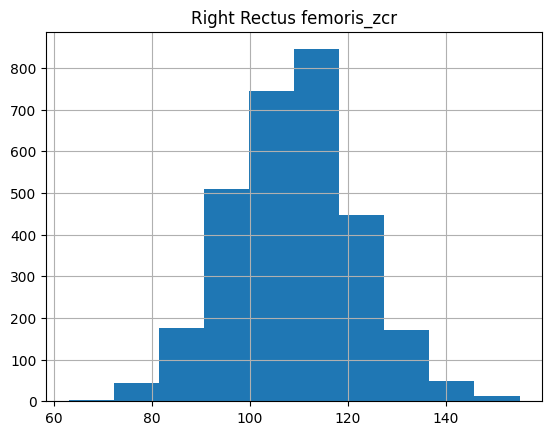

La estadistica descriptiva de la caracteristica Right Rectus femoris_mav

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_mav


count    3002.000000
mean        0.022596
std         0.015262
min         0.002243
25%         0.013461
50%         0.018516
75%         0.026945
max         0.128436
Name: Right Rectus femoris_mav, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  🔶 Sesgo fuerte positivo (cola derecha) (skewness=2.84) — considera transformación log/sqrt/Box-Cox.
  ⚠️  Curtosis alta (kurtosis=10.83) — colas pesadas, probables outliers significativos.
  ⚠️  Media (0.02) y Mediana (0.02) difieren (18.1%) — sesgo o outliers presentes.
  ✅ Variabilidad adecuada (CV=67.5%) — la feature tiene dispersión útil.
  ℹ️  Rango: [0.00 — 0.13] (amplitud=0.13)


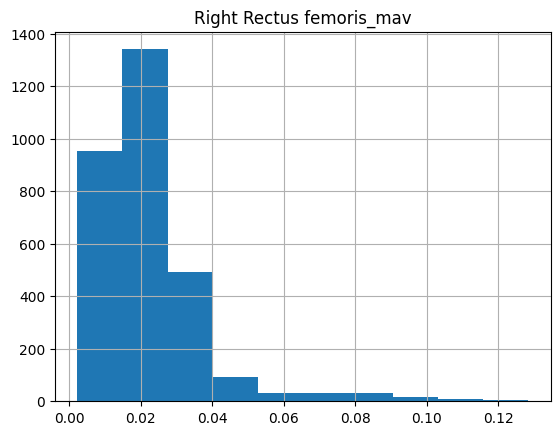

La estadistica descriptiva de la caracteristica Right Rectus femoris_pot

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_pot


count    3002.000000
mean        0.000483
std         0.000982
min         0.000002
25%         0.000099
50%         0.000223
75%         0.000444
max         0.011503
Name: Right Rectus femoris_pot, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  🔶 Sesgo fuerte positivo (cola derecha) (skewness=5.60) — considera transformación log/sqrt/Box-Cox.
  ⚠️  Curtosis alta (kurtosis=39.26) — colas pesadas, probables outliers significativos.
  🔶 Gran diferencia Media (0.00) vs Mediana (0.00) (53.8%) — outliers distorsionan la media.
  🔶 Variabilidad muy alta (CV=203.5%) — revisa outliers o considera normalización.
  ℹ️  Rango: [0.00 — 0.01] (amplitud=0.01)


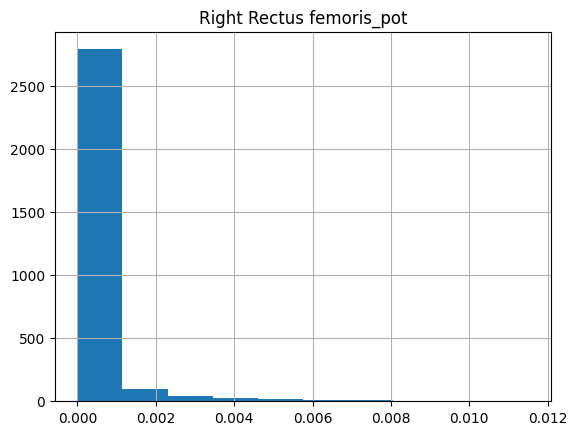

La estadistica descriptiva de la caracteristica Right Rectus femoris_f_media

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_f_media


count    3002.000000
mean       54.015741
std         6.264138
min        20.487091
25%        50.660326
50%        54.555808
75%        58.067109
max        71.694239
Name: Right Rectus femoris_f_media, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  ⚠️  Sesgo moderado (skewness=-0.92) — puede funcionar bien, monitorea el modelo.
  ⚠️  Curtosis alta (kurtosis=2.59) — colas pesadas, probables outliers significativos.
  ✅ Media (54.02) ≈ Mediana (54.56) — distribución balanceada.
  ⚠️  Baja variabilidad (CV=11.6%) — la feature puede aportar poca información al modelo.
  ℹ️  Rango: [20.49 — 71.69] (amplitud=51.21)


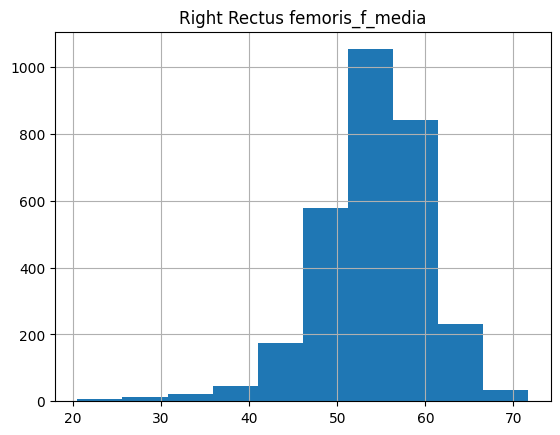

La estadistica descriptiva de la caracteristica Right Rectus femoris_f_mediana

  ESTADÍSTICA DESCRIPTIVA: Right Rectus femoris_f_mediana


count    3002.000000
mean       47.493078
std         8.368634
min        15.625000
25%        42.968750
50%        46.875000
75%        50.781250
max        74.218750
Name: Right Rectus femoris_f_mediana, dtype: float64


📋 CONSIDERACIONES:
  ✅ Sin valores nulos.
  ✅ Distribución simétrica (skewness=-0.42) — sin transformación necesaria.
  ⚠️  Curtosis alta (kurtosis=1.02) — colas pesadas, probables outliers significativos.
  ✅ Media (47.49) ≈ Mediana (46.88) — distribución balanceada.
  ✅ Variabilidad adecuada (CV=17.6%) — la feature tiene dispersión útil.
  ℹ️  Rango: [15.62 — 74.22] (amplitud=58.59)


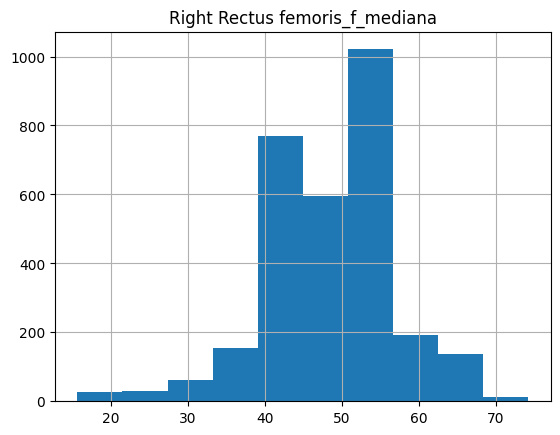

Estas son las features buenas
['Right Rectus femoris_zcr', 'Right Rectus femoris_f_media', 'Right Rectus femoris_f_mediana', 'Left Gluteus maximus_zcr', 'Left Gluteus maximus_f_media', 'Left Gluteus maximus_f_mediana', 'Left Gastrocnemius medialis_f_mediana', 'Left Semitendinosus_zcr', 'Left Semitendinosus_f_media', 'Left Biceps femoris caput longus_zcr', 'Right Vastus medialis_zcr', 'Right Vastus medialis_f_media', 'Right Vastus medialis_f_mediana', 'Right Tibialis anterior_zcr', 'Right Tibialis anterior_f_media', 'Right Tibialis anterior_f_mediana', 'Left Gastrocnemius lateralis_zcr']
Estas son las features decentes
['Right Rectus femoris_rms', 'Right Rectus femoris_mav', 'Left Gastrocnemius medialis_zcr', 'Left Gastrocnemius medialis_f_media', 'Left Semitendinosus_f_mediana', 'Left Biceps femoris caput longus_rms', 'Left Biceps femoris caput longus_mav', 'Left Biceps femoris caput longus_f_media', 'Left Biceps femoris caput longus_f_mediana', 'Right Vastus medialis_rms', 'Left Gastr

In [ ]:
# Descomentar si se quieren graficar todas las features

# for caracteristica in todos_los_musculos
for caracteristica in primer_musculo:
    print(f"La estadistica descriptiva de la caracteristica {caracteristica}")
    interpretar_estadisticas(nuevo_df[caracteristica], caracteristica)

    nuevo_df.hist(column=caracteristica)
    plt.show()


### Matriz de correlaciones

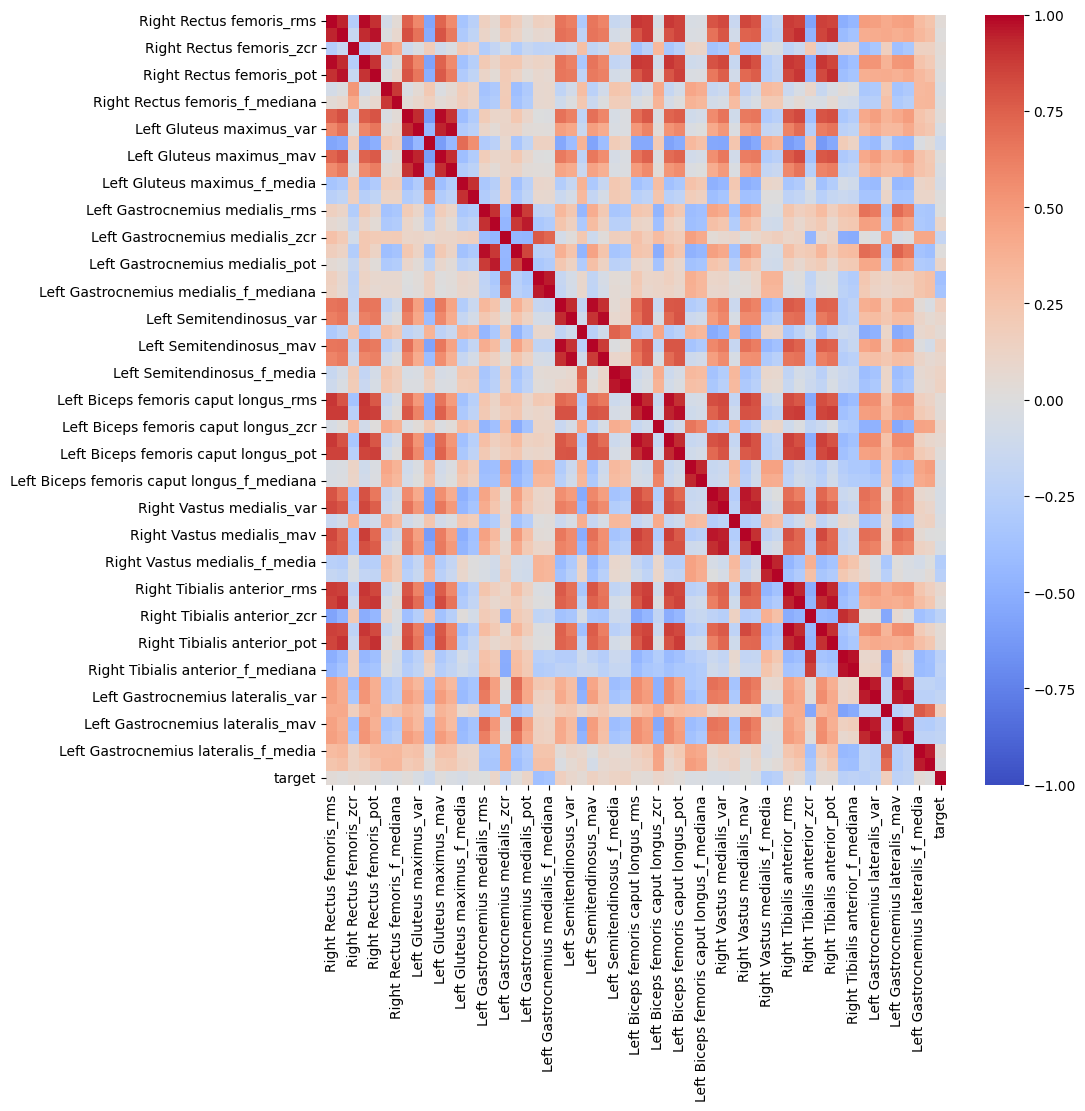

In [7]:
import seaborn as sns
corr = nuevo_df.corr(method='pearson')
plt.figure(figsize=(10 , 10))
sns.heatmap(
    corr,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
)
plt.show()

Ya que, como la matriz de correlaciones es simetrica, podemos observarla con unicamente ver la parte triangular superior o inferior sin la diagonal. En este caso vamos a ver la parte triangular superior

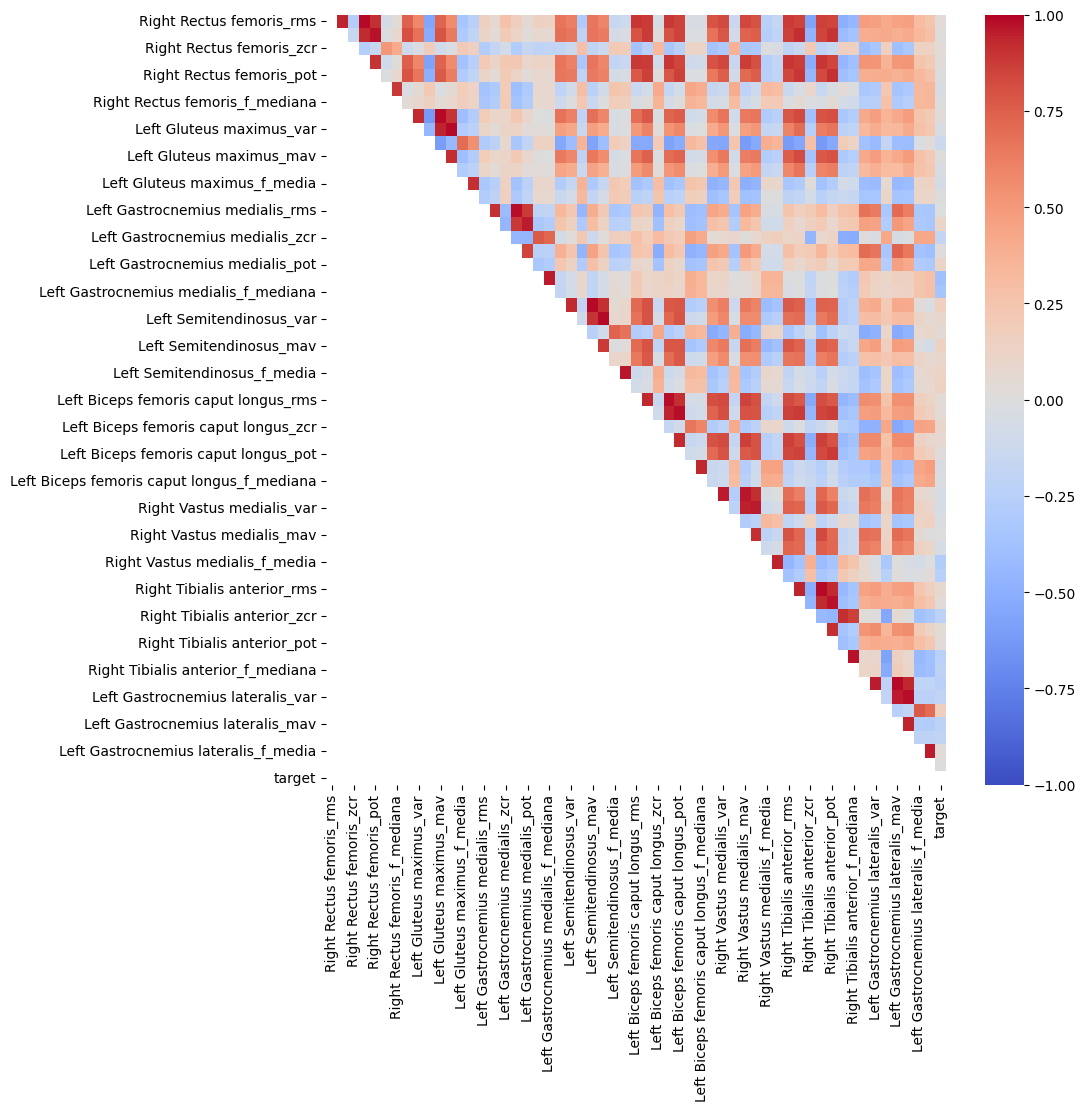

In [8]:
tri_superior = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)) # Triangular superior sin diagonal
plt.figure(figsize=(10 , 10))
sns.heatmap(
    tri_superior,
    cmap='coolwarm',
    vmin=-1, vmax=1,
    center=0,
)
plt.show()

In [9]:
top_20 = (
    tri_superior
    .stack()
    .reset_index()
)

top_20.columns = ['variable_1', 'variable_2', 'correlacion']
top_20['abs_corr'] = top_20['correlacion'].abs() # Util para ordenar. Una correlacion negativa tambien puede ser muy fuerte

top_20 = top_20.sort_values('abs_corr', ascending=False).head(20)

print(top_20)

                                variable_1  \
409               Left Gluteus maximus_rms   
1221               Left Semitendinosus_rms   
467               Left Gluteus maximus_var   
3                 Right Rectus femoris_rms   
2845      Left Gastrocnemius lateralis_rms   
2439           Right Tibialis anterior_rms   
1279               Left Semitendinosus_var   
1627  Left Biceps femoris caput longus_rms   
815        Left Gastrocnemius medialis_rms   
2903      Left Gastrocnemius lateralis_var   
1685  Left Biceps femoris caput longus_var   
61                Right Rectus femoris_var   
2727       Right Tibialis anterior_f_media   
2497           Right Tibialis anterior_var   
2033             Right Vastus medialis_rms   
1509           Left Semitendinosus_f_media   
1103   Left Gastrocnemius medialis_f_media   
2031             Right Vastus medialis_rms   
2902      Left Gastrocnemius lateralis_var   
873        Left Gastrocnemius medialis_var   

                                 

### Correlaciones

Se puede observar que hay una gran cantidad de features altamente correlacionadas entre sí (con coeficientes cercanos a 1). Esto introduce redundancia en los datos, lo que equivale a pasarle la misma información al modelo dos veces. Como consecuencia, ciertos modelos pueden tener dificultades asignando pesos a estas features, ya que no existe una distinción clara entre su contribución individual al aprendizaje.

Frente a esto, existen dos enfoques principales. El primero es eliminar directamente una de las features correlacionadas, conservando aquella que tenga mayor correlación con el target — es la opción más simple e interpretable. El segundo es aplicar PCA, que en lugar de descartar información, la combina en componentes que capturan la varianza útil de ambas features simultáneamente — es más adecuado cuando la redundancia es generalizada en el dataset. La elección entre uno u otro dependerá del modelo que se utilice y de qué tan importante sea mantener la interpretabilidad de las features.

### Relación entre características-target y análisis de balance de clases

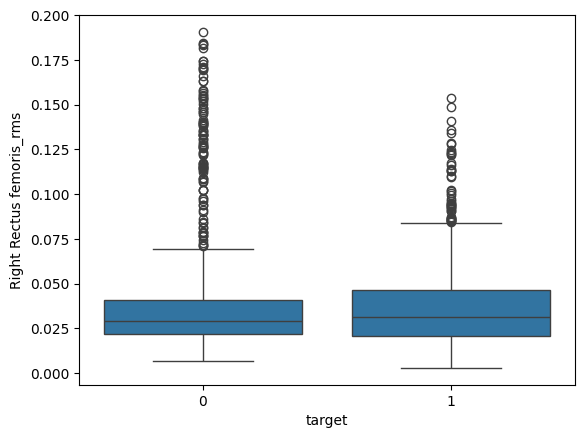

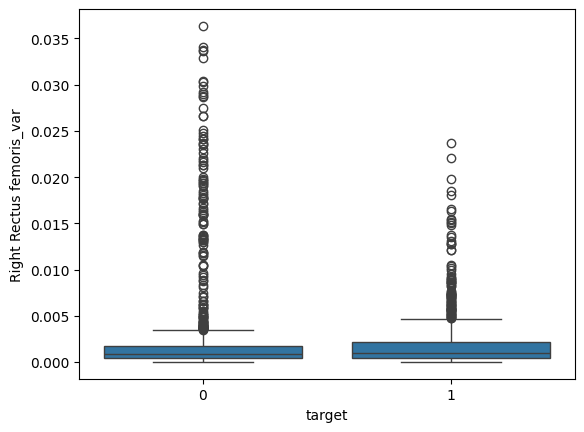

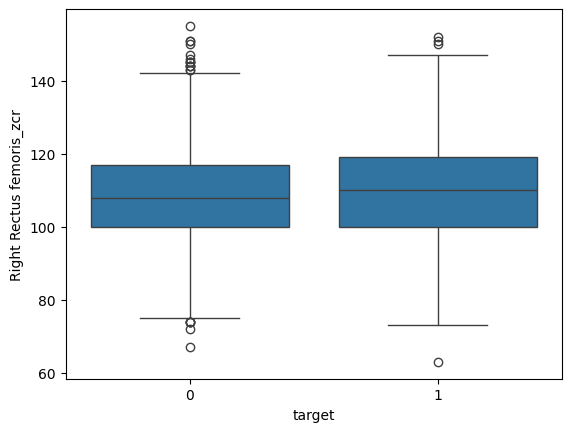

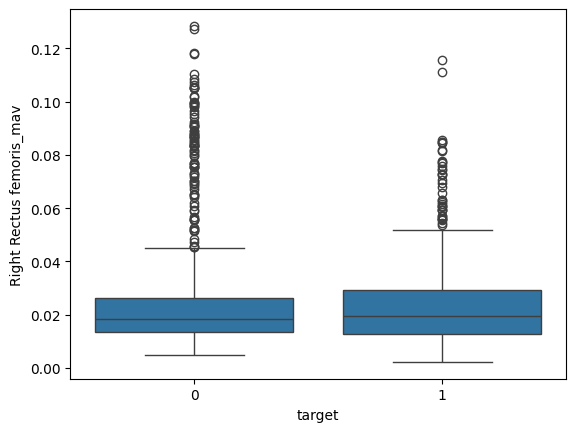

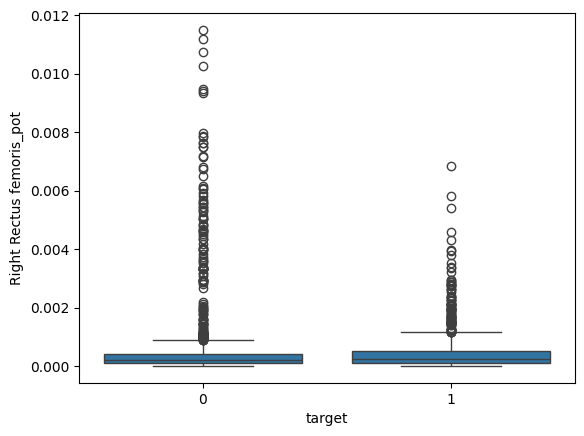

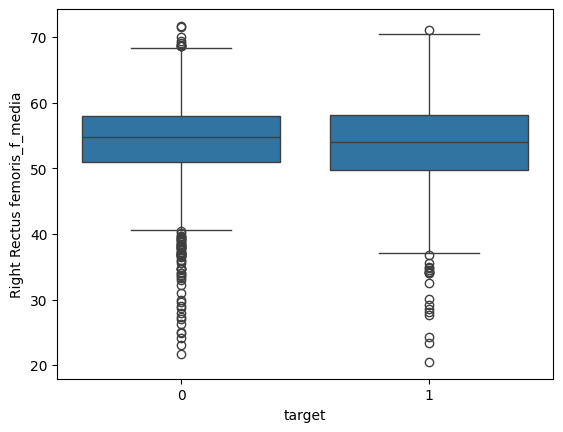

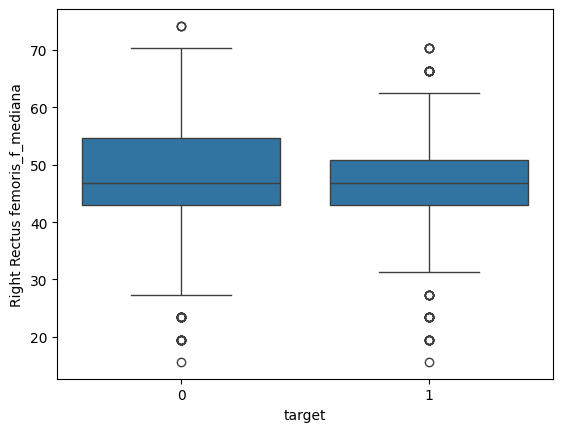

Proporciones de las clases


target
0    2128
1     874
Name: count, dtype: int64

target
0    70.886076
1    29.113924
Name: proportion, dtype: float64

In [10]:
for caracteristica in primer_musculo:
    sns.boxplot(x=nuevo_df['target'], y=nuevo_df[caracteristica])
    plt.show()

print("Proporciones de las clases")
display(nuevo_df['target'].value_counts())
display(nuevo_df['target'].value_counts(normalize=True) * 100)

### Balance de clases

Se observa un desbalance moderado entre las clases del target, con un 70.9% correspondiente a la clase 0 (No fatigado) y un 29.1% a la clase 1 (Fatigado). 

Esto es importante tenerlo en cuenta durante el modelado, ya que un modelo que predijera siempre la clase mayoritaria obtendría un accuracy del ~71% sin haber aprendido ningún patrón real. Por esta razón, el accuracy no será una métrica confiable para evaluar el desempeño — se priorizarán métricas como F1-Score y se considerará el uso de class_weight='balanced' para que el modelo penalice proporcionalmente los errores en la clase minoritaria.

In [64]:
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import entropy

PESOS = {
    'nulos':        0.30,
    'variabilidad': 0.25,
    'correlacion':  0.30,
    'sesgo':        0.15,
}

def normalizar(score, target):
    _, conteos = np.unique(target, return_counts=True)
    probs = conteos / conteos.sum()
    entropia_target = entropy(probs, base=2)
    if entropia_target == 0:
        return 0.0
    return min(score / entropia_target, 1.0)

def score_feature(serie, _, target):
    pct_nulos = serie.isnull().mean()
    skewness  = abs(serie.skew())
    media     = serie.mean()
    cv        = serie.std() / media if media != 0 else 0

    # --- Nulos ---
    if pct_nulos == 0:           s_nulos = 1.0
    elif pct_nulos <= 0.05:      s_nulos = 0.7
    elif pct_nulos <= 0.30:      s_nulos = 0.3
    else:                        s_nulos = 0.0

    # --- Variabilidad ---
    if cv == 0:                  s_var = 0.0
    elif cv < 0.15:              s_var = 0.3
    elif cv <= 1.0:              s_var = 1.0
    else:                        s_var = 0.6

    # --- Sesgo ---
    if skewness < 0.5:           s_sesgo = 1.0
    elif skewness < 1.0:         s_sesgo = 0.6
    else:                        s_sesgo = 0.3

    # --- Correlación con target (Mutual Information) ---
    serie_limpia     = serie.dropna()
    target_alineado  = target[serie_limpia.index]

    raw  = mutual_info_classif(
        serie_limpia.values.reshape(-1, 1),
        target_alineado,
        random_state=42
    )[0]

    s_corr = normalizar(raw, target_alineado)

    # --- Score final ponderado ---
    score = (
        s_nulos  * PESOS['nulos']       +
        s_var    * PESOS['variabilidad'] +
        s_sesgo  * PESOS['sesgo']       +
        s_corr   * PESOS['correlacion']
    )

    return round(score, 3)


features_malas    = []
features_decentes = []
features_buenas   = []

for caracteristica in todos_los_musculos:
    score = score_feature(nuevo_df[caracteristica], caracteristica, nuevo_df['target'])  # Cambia 'target' por tu columna
    
    print(f"Feature: {caracteristica:<30} Score: {score:.3f}", end="  →  ")
    
    if score < 0.50:
        print("🔴 Mala")
        features_malas.append(caracteristica)
    elif score < 0.70:
        print("🟡 Decente")
        features_decentes.append(caracteristica)
    else:
        print("🟢 Buena")
        features_buenas.append(caracteristica)

# --- Resumen final ---
print(f"\n{'='*50}")
print(f"🟢 Features buenas   ({len(features_buenas)}):   {features_buenas}")
print(f"🟡 Features decentes ({len(features_decentes)}): {features_decentes}")
print(f"🔴 Features malas    ({len(features_malas)}):    {features_malas}")

Feature: Right Rectus femoris_rms       Score: 0.602  →  🟡 Decente
Feature: Right Rectus femoris_var       Score: 0.502  →  🟡 Decente
Feature: Right Rectus femoris_zcr       Score: 0.525  →  🟡 Decente
Feature: Right Rectus femoris_mav       Score: 0.601  →  🟡 Decente
Feature: Right Rectus femoris_pot       Score: 0.508  →  🟡 Decente
Feature: Right Rectus femoris_f_media   Score: 0.465  →  🔴 Mala
Feature: Right Rectus femoris_f_mediana Score: 0.700  →  🟢 Buena
Feature: Left Gluteus maximus_rms       Score: 0.509  →  🟡 Decente
Feature: Left Gluteus maximus_var       Score: 0.509  →  🟡 Decente
Feature: Left Gluteus maximus_zcr       Score: 0.470  →  🔴 Mala
Feature: Left Gluteus maximus_mav       Score: 0.509  →  🟡 Decente
Feature: Left Gluteus maximus_pot       Score: 0.502  →  🟡 Decente
Feature: Left Gluteus maximus_f_media   Score: 0.706  →  🟢 Buena
Feature: Left Gluteus maximus_f_mediana Score: 0.645  →  🟡 Decente
Feature: Left Gastrocnemius medialis_rms Score: 0.616  →  🟡 Decente
Feat

### Conclusiones del EDA

Las únicas features que superaron un umbral del 70% en la suma ponderada de calidad de datos valores nulos, variabilidad, sesgo y correlación con el target fueron las siguientes 7:

- Right Rectus femoris_f_mediana
- Left Gluteus maximus_f_media
- Left Semitendinosus_zcr
- Right Vastus medialis_f_mediana
- Right Tibialis anterior_f_media
- Right Tibialis anterior_f_mediana
- Left Gastrocnemius lateralis_zcr

Analizar estas métricas de forma conjunta fue fundamental, ya que cada una por separado puede llevar a conclusiones incorrectas.

Si solo hubiéramos observado los histogramas y estadísticos descriptivos, podríamos haber descartado features con alta asimetría asumiendo que no aportarían información útil al modelo. Sin embargo, la asimetría afecta principalmente a modelos paramétricos y no determina por sí sola si una feature es informativa.

Si solo hubiéramos analizado los boxplots, podríamos haber eliminado features con muchos outliers bajo el supuesto de que representaban ruido. No obstante, en señales fisiológicas como las de este dataset, los valores extremos pueden corresponder a eventos musculares relevantes y no necesariamente a errores de medición.

Esta información se complementa de gran manera al incorporar la correlación entre cada feature y el target. La presencia de una correlación significativa entre una característica y la variable objetivo (en este caso una clasificación 0 o 1) indica que dicha feature contiene información valiosa que el modelo puede aprovechar para realizar predicciones más acertadas.

En conclusión, ninguna métrica aislada es suficiente para determinar si una feature es útil. Una distribución perfectamente normal no garantiza poder predictivo. Una variabilidad adecuada no sirve si hay un porcentaje crítico de valores nulos. Y una alta correlación con el target pierde valor si la feature carece de variabilidad real o está plagada de datos faltantes.

La decisión más robusta se obtiene evaluando todas estas dimensiones de forma simultánea, ponderando cada una según su impacto real en el aprendizaje del modelo, obteniendo así las features más robustas que, estadísticamente, aportan mayor valor predictivo.

### Señales en el tiempo

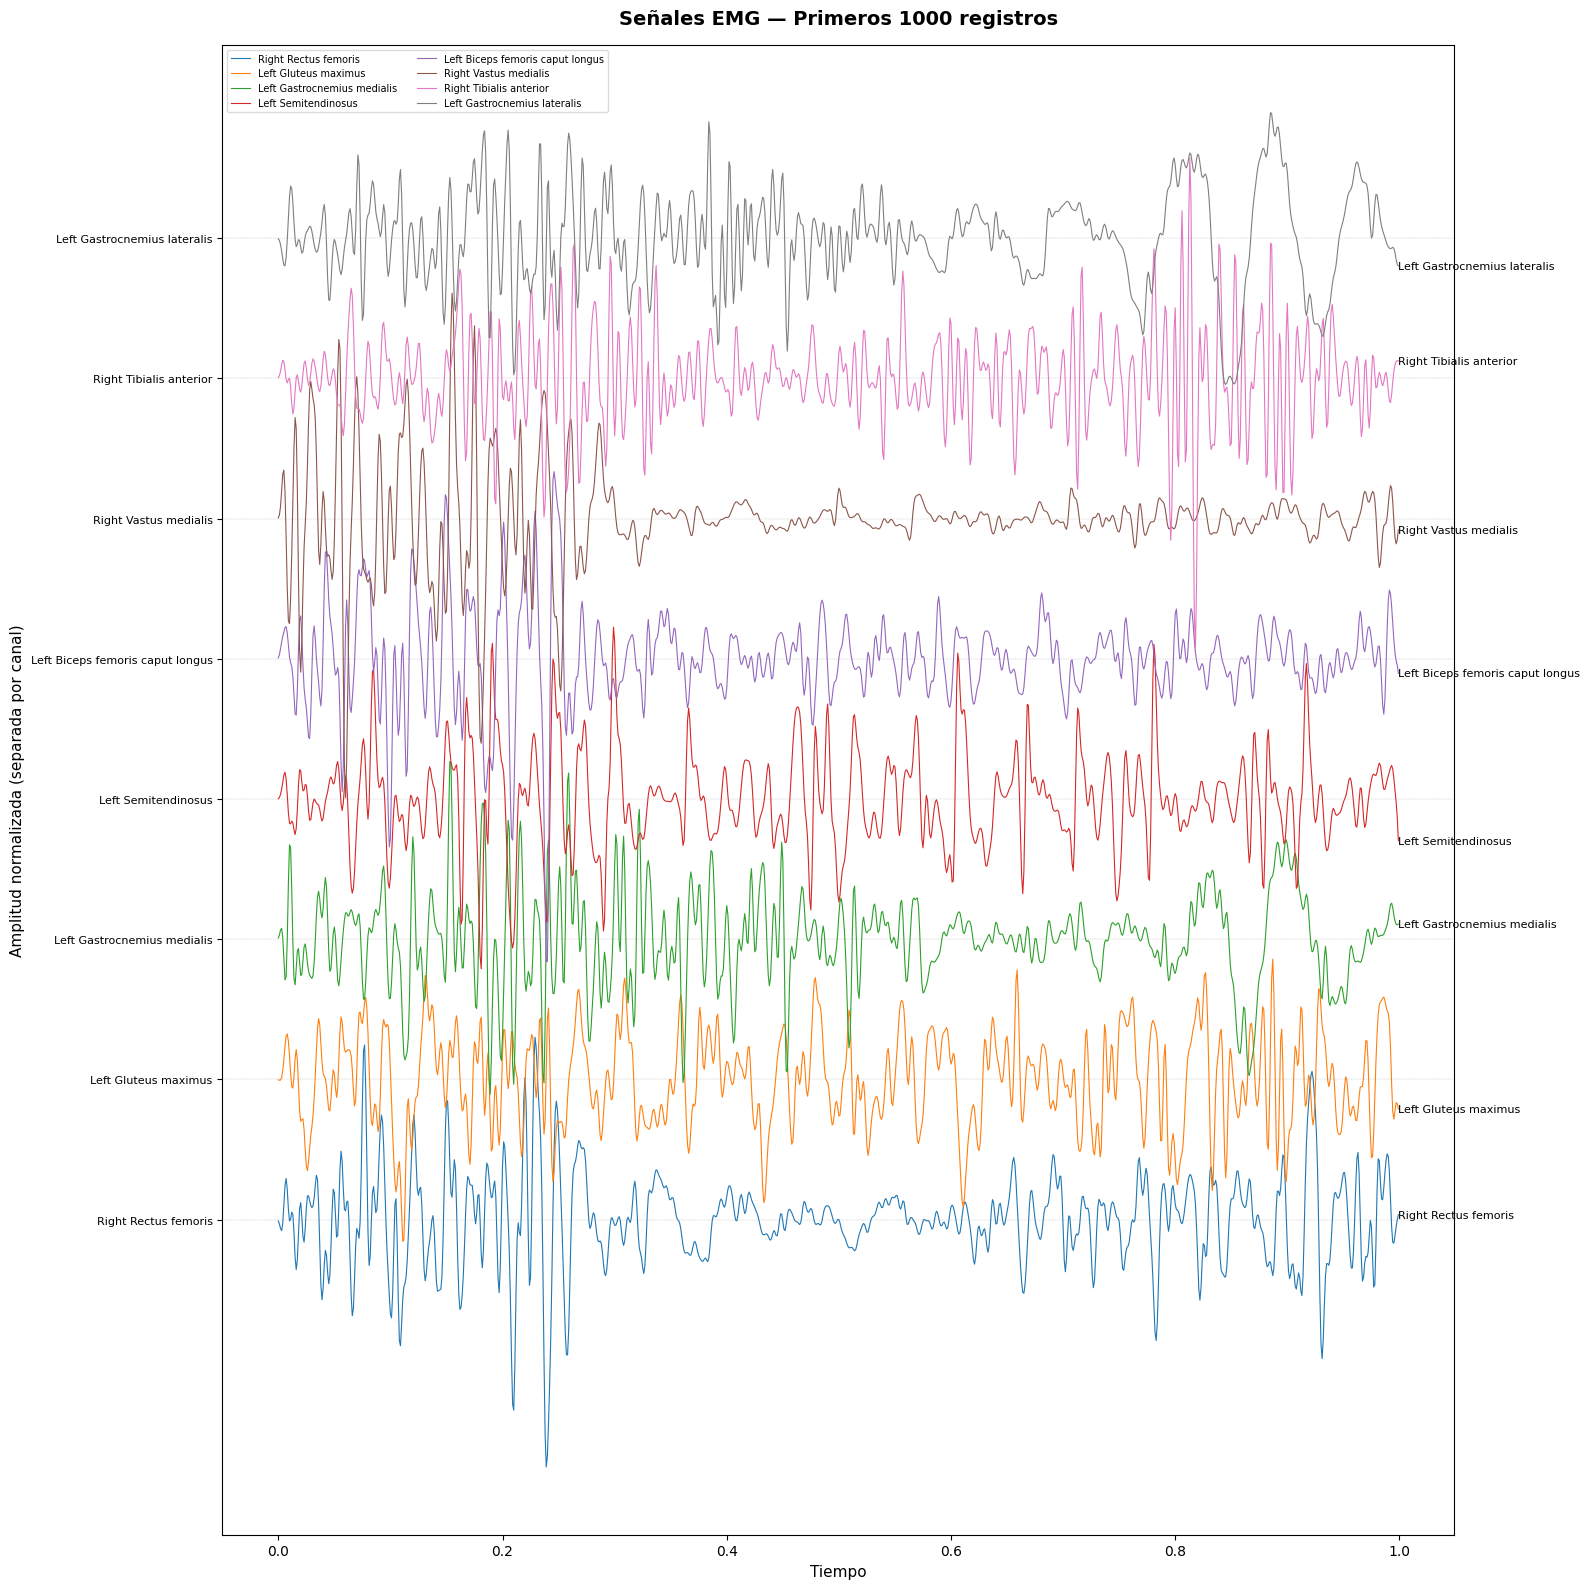

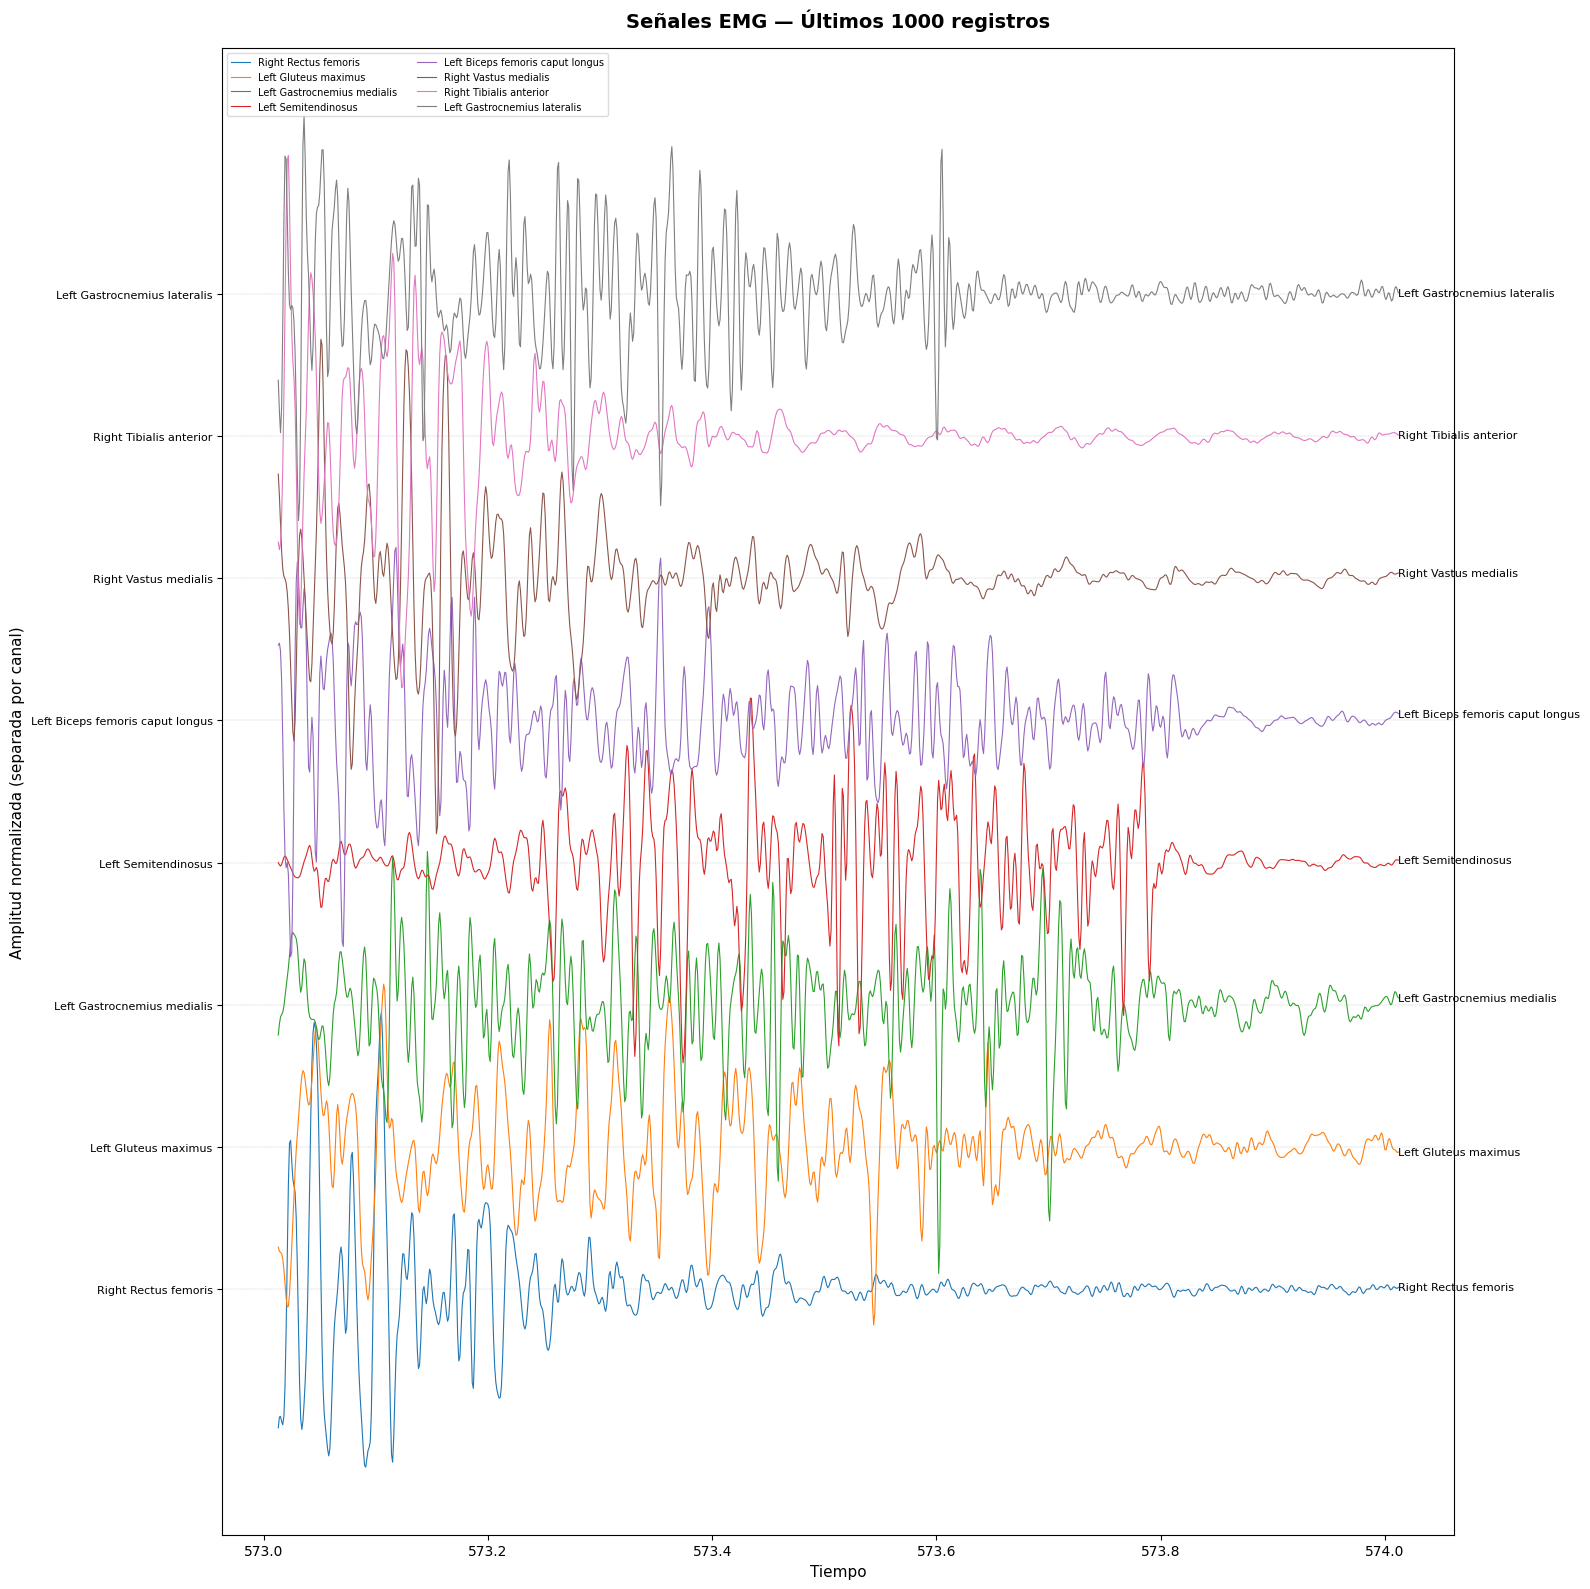

In [69]:
def plot_emg(data, titulo, channels):
    _, ax = plt.subplots(figsize=(16, len(channels) * 2))
    
    # Offset para separar visualmente cada señal
    offset_scale = 3  # Ajusta este valor si las señales siguen solapándose
    
    for i, channel in enumerate(channels):
        señal = data[channel].values
        # Normalizar cada señal para que tengan escala comparable
        señal_norm = (señal - np.mean(señal)) / (np.std(señal) + 1e-8)
        offset = i * offset_scale
        
        ax.plot(data['Time'].values, señal_norm + offset, 
                label=channel, linewidth=0.8)
        
        # Label a la derecha de cada señal
        ax.text(x=data['Time'].values[-1], 
                y=señal_norm[-1] + offset,
                s=channel, 
                fontsize=8, 
                va='center',
                ha='left')
        
        # Línea base punteada por canal para facilitar lectura
        ax.axhline(y=offset, color='gray', linewidth=0.3, linestyle='--', alpha=0.5)
    
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Tiempo', fontsize=11)
    ax.set_ylabel('Amplitud normalizada (separada por canal)', fontsize=11)
    ax.legend(loc='upper left', fontsize=7, ncol=2, 
              bbox_to_anchor=(0, 1), framealpha=0.7)
    
    # Quitar los ticks del eje Y ya que el offset los hace poco informativos
    ax.set_yticks([i * offset_scale for i in range(len(channels))])
    ax.set_yticklabels(channels, fontsize=8)
    
    plt.tight_layout()
    plt.show()


# --- Uso ---
plot_emg(df.head(1000), 'Señales EMG — Primeros 1000 registros', channels)
plot_emg(df.tail(1000), 'Señales EMG — Últimos 1000 registros', channels)

### ¿Qué se puede observar de las señales en el tiempo?

En los primeros 1000 registros del dataset, se observa una actividad muscular intensa en la mayoría de los canales, con picos de alta amplitud que reflejan contracciones activas. El músculo que presenta menor actividad en este intervalo es el Right Vastus medialis, mientras que el Right Tibialis anterior y el left biceps femoris caput longus muestran los picos más pronunciados.

En los últimos 1000 registros se puede apreciar un patrón diferente: aunque inicialmente las señales mantienen una actividad considerable, aproximadamente a partir del segundo 573.5 la amplitud de todas las señales converge progresivamente hacia cero. Esto sugiere que los participantes cesaron la actividad física en ese punto, lo que se refleja en la ausencia de contracciones musculares detectables hacia el final del registro.

Esta diferencia entre el inicio y el final del dataset es relevante, ya que podría indicar que las últimas ventanas de tiempo corresponden a un estado de reposo y no de fatiga activa, lo cual debe tenerse en cuenta al interpretar las etiquetas del target en esa región temporal.

## Paso 4: Procesamiento de Datos

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Separar variables predictoras y target
X = nuevo_df.drop(columns='target')
y = nuevo_df['target']

# 2. División 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# 3. Pipeline de preprocesamiento
pipeline_preprocesamiento = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 4. Calcular mediana en train, para luego imputar en los demas datasets
X_train_proc = pipeline_preprocesamiento.fit_transform(X_train)
X_val_proc = pipeline_preprocesamiento.transform(X_val)
X_test_proc = pipeline_preprocesamiento.transform(X_test)

# 5. Verificación
total_registros = X_train_proc.shape[0] + X_val_proc.shape[0] + X_test_proc.shape[0] 
print("Porcentajes de las clases:")
print("X_train:", X_train_proc.shape[0] / total_registros * 100 , "%") 
print("X_val:", X_val_proc.shape[0] / total_registros * 100 , "%") 
print("X_test:", X_test_proc.shape[0] / total_registros * 100 , "%") 

print("\nDistribución de clases:")
print("Train:")
print(y_train.value_counts(normalize=True))
print("\nVal:")
print(y_val.value_counts(normalize=True))
print("\nTest:")
print(y_test.value_counts(normalize=True))

Porcentajes de las clases:
X_train: 69.98667554963359 %
X_val: 14.990006662225182 %
X_test: 15.023317788141238 %

Distribución de clases:
Train:
target
0    0.70871
1    0.29129
Name: proportion, dtype: float64

Val:
target
0    0.708889
1    0.291111
Name: proportion, dtype: float64

Test:
target
0    0.709534
1    0.290466
Name: proportion, dtype: float64


## Paso 5: Entrenamiento y Comparación de Modelos

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

from scipy.stats import randint

from sklearn.model_selection import RandomizedSearchCV

param_dist_neighbors = {
    'n_neighbors': randint(1, 30), # Distribucion uniforme discreta    
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski', 'chebyshev'],
}

kneighbors = RandomizedSearchCV (
    estimator= KNeighborsClassifier(),
    param_distributions=param_dist_neighbors,
    n_iter=50,
    cv=5, # Hace CV 5 veces, rotando cual va a ser la particion VAL en cada cv
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
)

kneighbors.fit(X_train_proc , y_train)
print("Los mejores parametros:" , kneighbors.best_params_)
print("Mejor accuracy:" , kneighbors.best_score_)



Los mejores parametros: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Mejor accuracy: 0.8634851067502618


In [ ]:
param_dist_dt = {
    'criterion' : ['gini' , 'entropy' , 'log_loss'],
    'splitter' : ['best' , 'random'],
    'max_depth' : [3, 5, 7],
    'class_weight': ['balanced', None]
}

decision_tree = RandomizedSearchCV (
    estimator = DecisionTreeClassifier(),
    param_distributions = param_dist_dt,
    n_iter=50,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
)

decision_tree.fit(X_train_proc , y_train)
print("Los mejores parametros:" , decision_tree.best_params_)
print("Mejor accuracy:" , decision_tree.best_score_)

/home/alejo/Universidad/IA/Taller2/venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 18 is smaller than n_iter=50. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Los mejores parametros: {'splitter': 'best', 'max_depth': 7, 'criterion': 'gini'}
Mejor accuracy: 0.83628096369189


In [17]:
param_dist_rf = {
    'n_estimators' : [100,200,300],
    'criterion' : ['gini' , 'entropy' , 'log_loss'],
    'max_depth' : [3, 5, 7],
    'max_features': ['sqrt', 'log2']
}

ramdom_forest = RandomizedSearchCV (
    estimator=RandomForestClassifier(),
    param_distributions=param_dist_rf,
    n_iter=50,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

ramdom_forest.fit(X_train_proc , y_train)
print("Los mejores parametros:" , ramdom_forest.best_params_)
print("Mejor accuracy:" , ramdom_forest.best_score_)

Los mejores parametros: {'n_estimators': 200, 'max_features': 'sqrt', 'max_depth': 7, 'criterion': 'log_loss'}
Mejor accuracy: 0.8577888454234042


In [18]:
param_dist_gb = {
    'n_estimators'  : [100, 200, 300],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'max_depth'     : [3, 5, 7],
    'subsample'     : [0.7, 0.8, 1.0],
    'loss' : ['log_loss' , 'exponential']
}

gradient_boosting = RandomizedSearchCV (
    estimator= GradientBoostingClassifier(),
    param_distributions=param_dist_gb,
    n_iter=50,
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1
)

gradient_boosting.fit(X_train_proc , y_train)
print("Los mejores parametros:" , gradient_boosting.best_params_)
print("Mejor accuracy:" , gradient_boosting.best_score_)

Los mejores parametros: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'loss': 'exponential', 'learning_rate': 0.2}
Mejor accuracy: 0.874039283717041


In [32]:
from tensorflow.keras.metrics import Precision, Recall
import tensorflow as tf

# F1 no existe nativa, pero se puede construir
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall    = Recall()

    def update_state(self, y_true, y_pred, sample_weight=None):
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * (p * r) / (p + r + 1e-6)  # +1e-6 evita división por cero

    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.layers import Input
from scipy.stats import uniform

def crear_modelo(units_1=128, units_2=64, units_3=32,
                 dropout_rate=0.3, learning_rate=0.001, l2_lambda=0.001):
    model = Sequential([
        Input(shape=(X_train_proc.shape[1],)),  # ← capa Input explícita
        Dense(units_1, activation='relu', kernel_regularizer=l2(l2_lambda)),
        Dropout(dropout_rate),

        Dense(units_2, activation='relu', kernel_regularizer=l2(l2_lambda)),
        Dropout(dropout_rate),

        Dense(units_3, activation='relu', kernel_regularizer=l2(l2_lambda)),
        Dropout(dropout_rate * 0.7),  # La última capa siempre un poco menos

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            Precision(name='precision'),
            Recall(name='recall'),
            F1Score(name='f1_score')
        ]
    )
    return model

early_stopping = EarlyStopping(
    monitor='loss',    # Vigila la pérdida en validación
    patience=10,           # Para si no mejora en 10 épocas seguidas
    restore_best_weights=True  # Recupera los pesos del mejor epoch
)

modelo_keras = KerasClassifier(
    model=crear_modelo,
    epochs=50,
    batch_size=32,
    verbose=0,
    callbacks=[early_stopping]
)

param_dist = {
    'model__units_1':       randint(64, 256),     # Neuronas capa 1
    'model__units_2':       randint(32, 128),      # Neuronas capa 2
    'model__units_3':       randint(16, 64),       # Neuronas capa 3
    'model__dropout_rate':  uniform(0.1, 0.4),     # Dropout entre 0.1 y 0.5
    'model__learning_rate': uniform(0.0001, 0.01), # Learning rate
    'model__l2_lambda':     uniform(0.0001, 0.01), # Regularización L2
    'batch_size':           [16, 32, 64]           # Tamaño de batch
}

dnn = RandomizedSearchCV(
    estimator=modelo_keras,
    param_distributions=param_dist,
    n_iter=20,          
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=1            # Con Keras siempre n_jobs=1, no paraleliza bien
)

dnn.fit(X_train_proc , y_train)
print("Los mejores parametros:" , dnn.best_params_)
print("Mejor accuracy:" , dnn.best_score_)

mejor_modelo = dnn.best_estimator_
accuracy_test = mejor_modelo.score(X_test_proc, y_test)
print(f"Test Accuracy: {accuracy_test:.4f}")



Los mejores parametros: {'batch_size': 16, 'model__dropout_rate': np.float64(0.191519266196649), 'model__l2_lambda': np.float64(0.00086979909828793), 'model__learning_rate': np.float64(0.00299751452913768), 'model__units_1': 149, 'model__units_2': 59, 'model__units_3': 17}
Mejor accuracy: 0.8672016740187761
Test Accuracy: 0.8692


In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Extraer el mejor estimador de cada Random Search
mejor_knn = kneighbors.best_estimator_
mejor_dt = decision_tree.best_estimator_
mejor_rf  = ramdom_forest.best_estimator_
mejor_gb  = gradient_boosting.best_estimator_
mejor_dnn = dnn.best_estimator_

modelos = {
    'KNN':               mejor_knn,
    'Random Forest':     mejor_rf,
    'Gradient Boosting': mejor_gb,
    'Decision Tree Classifier' : mejor_dt,
    'DNN':               mejor_dnn
}

print(modelos)

def calcular_metricas(nombre, modelo, X, y, conjunto):
    y_pred = modelo.predict(X)
    return {
        'Modelo':    nombre,
        'Conjunto':  conjunto,
        'Accuracy':  accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred, zero_division=0),
        'Recall':    recall_score(y, y_pred, zero_division=0),
        'F1-Score':  f1_score(y, y_pred, zero_division=0)
    }

{'KNN': KNeighborsClassifier(metric='manhattan', n_neighbors=6, weights='distance'), 'Random Forest': RandomForestClassifier(criterion='log_loss', max_depth=7, n_estimators=200), 'Gradient Boosting': GradientBoostingClassifier(learning_rate=0.2, loss='exponential', max_depth=5,
                           subsample=0.8), 'Decision Tree Classifier': DecisionTreeClassifier(max_depth=7), 'DNN': KerasClassifier(
	model=<function crear_modelo at 0x7d3fb9115f80>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=16
	validation_batch_size=None
	verbose=0
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x7d3f5140e450>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=50
	class_weight=None
	model__dropout_rate=0.191519266196649
	model__l2_lambda=0.00086979909828793
	model__learning_rate=0.00299751452913768
	model__units_1=149
	model__units_2=59
	model__units_3=17
)}


In [35]:
resultados = []

for nombre, modelo in modelos.items():
    resultados.append(calcular_metricas(nombre, modelo, X_train_proc, y_train, 'Train'))
    resultados.append(calcular_metricas(nombre, modelo, X_val_proc,   y_val,   'Val'))
    resultados.append(calcular_metricas(nombre, modelo, X_test_proc,  y_test,  'Test'))

df_resultados = pd.DataFrame(resultados)

# Formatear a 4 decimales
df_display = df_resultados.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_display[col] = df_display[col].map('{:.4f}'.format)

print(df_display.to_string(index=False))

                  Modelo Conjunto Accuracy Precision Recall F1-Score
                     KNN    Train   1.0000    1.0000 1.0000   1.0000
                     KNN      Val   0.8511    0.7807 0.6794   0.7265
                     KNN     Test   0.8825    0.8362 0.7405   0.7854
           Random Forest    Train   0.9091    0.9450 0.7304   0.8240
           Random Forest      Val   0.8444    0.7905 0.6336   0.7034
           Random Forest     Test   0.8914    0.8727 0.7328   0.7967
       Gradient Boosting    Train   1.0000    1.0000 1.0000   1.0000
       Gradient Boosting      Val   0.8622    0.8000 0.7023   0.7480
       Gradient Boosting     Test   0.8914    0.8361 0.7786   0.8063
Decision Tree Classifier    Train   0.9024    0.9453 0.7059   0.8082
Decision Tree Classifier      Val   0.8289    0.7755 0.5802   0.6638
Decision Tree Classifier     Test   0.8603    0.8400 0.6412   0.7273
                     DNN    Train   0.9381    0.8754 0.9183   0.8963
                     DNN      Val 

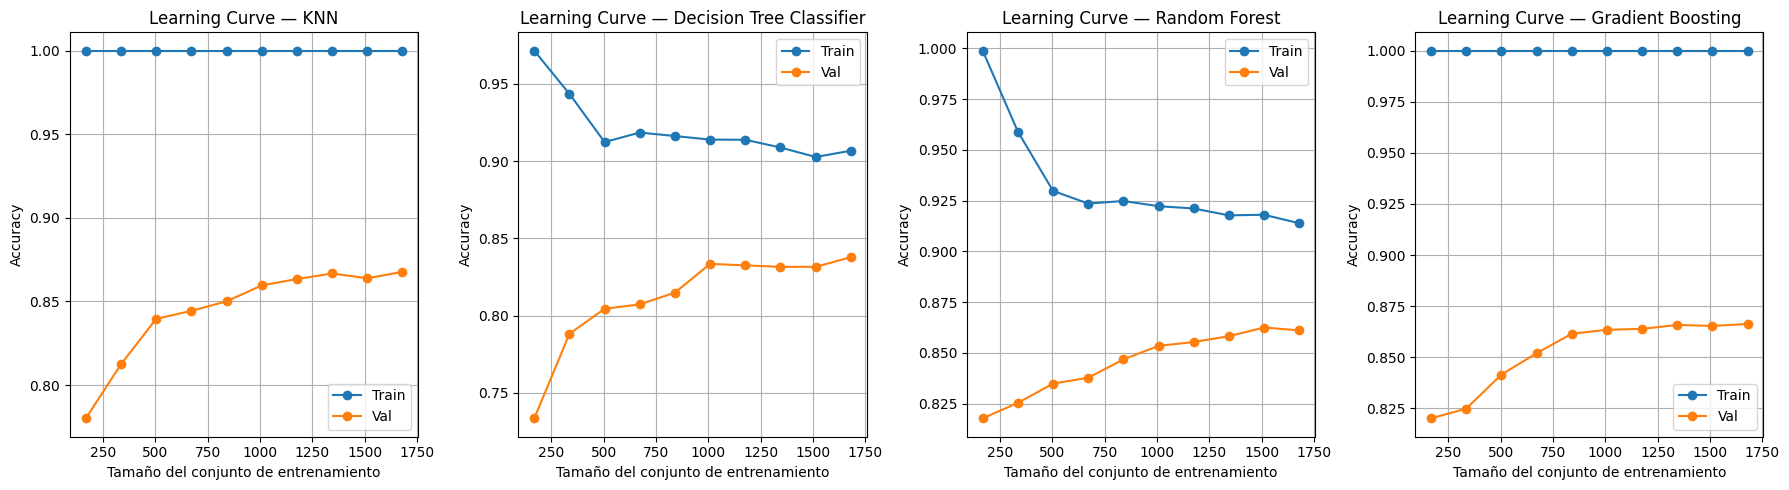

In [45]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

modelos_sklearn = {
    'KNN': mejor_knn,
    'Decision Tree Classifier' : mejor_dt,
    'Random Forest': mejor_rf,
    'Gradient Boosting': mejor_gb
}

for ax, (nombre, modelo) in zip(axes, modelos_sklearn.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_train_proc, y_train,
        cv=5, scoring='accuracy',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)

    ax.plot(train_sizes, train_mean, label='Train', marker='o')
    ax.plot(train_sizes, val_mean,   label='Val',   marker='o')
    ax.set_title(f'Learning Curve — {nombre}')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [42]:
mejor_params = dnn.best_params_

modelo_final_dnn = crear_modelo(
    units_1       = mejor_params['model__units_1'],
    units_2       = mejor_params['model__units_2'],
    units_3       = mejor_params['model__units_3'],
    dropout_rate  = mejor_params['model__dropout_rate'],
    learning_rate = mejor_params['model__learning_rate'],
    l2_lambda     = mejor_params['model__l2_lambda']
)

early_stopping_final = EarlyStopping(
    monitor='val_loss',         # ← ahora sí podemos usar val_loss
    patience=10,
    restore_best_weights=True
)

history = modelo_final_dnn.fit(
    X_train_proc, y_train,
    validation_data=(X_val_proc, y_val),  # ← ahora sí pasamos validación
    epochs=100,
    batch_size=mejor_params['batch_size'],
    callbacks=[early_stopping_final],
    verbose=1
)

Epoch 1/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7720 - f1_score: 0.5585 - loss: 0.6375 - precision: 0.6406 - recall: 0.4951 - val_accuracy: 0.8156 - val_f1_score: 0.6556 - val_loss: 0.5441 - val_precision: 0.7182 - val_recall: 0.6031
Epoch 2/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8168 - f1_score: 0.6655 - loss: 0.5300 - precision: 0.7106 - recall: 0.6258 - val_accuracy: 0.7933 - val_f1_score: 0.5753 - val_loss: 0.5382 - val_precision: 0.7159 - val_recall: 0.4809
Epoch 3/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8206 - f1_score: 0.6661 - loss: 0.5033 - precision: 0.7273 - recall: 0.6144 - val_accuracy: 0.7956 - val_f1_score: 0.6320 - val_loss: 0.4844 - val_precision: 0.6639 - val_recall: 0.6031
Epoch 4/100
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8282 - f1_score: 0.6791 - loss: 0.4770 - precision: 0.7446 - recall: 0.6242 - val_accuracy: 0.8267 - val_f1_score: 0.6977 - val_loss: 0.4784 - val_precision: 0.7087 - val_rec

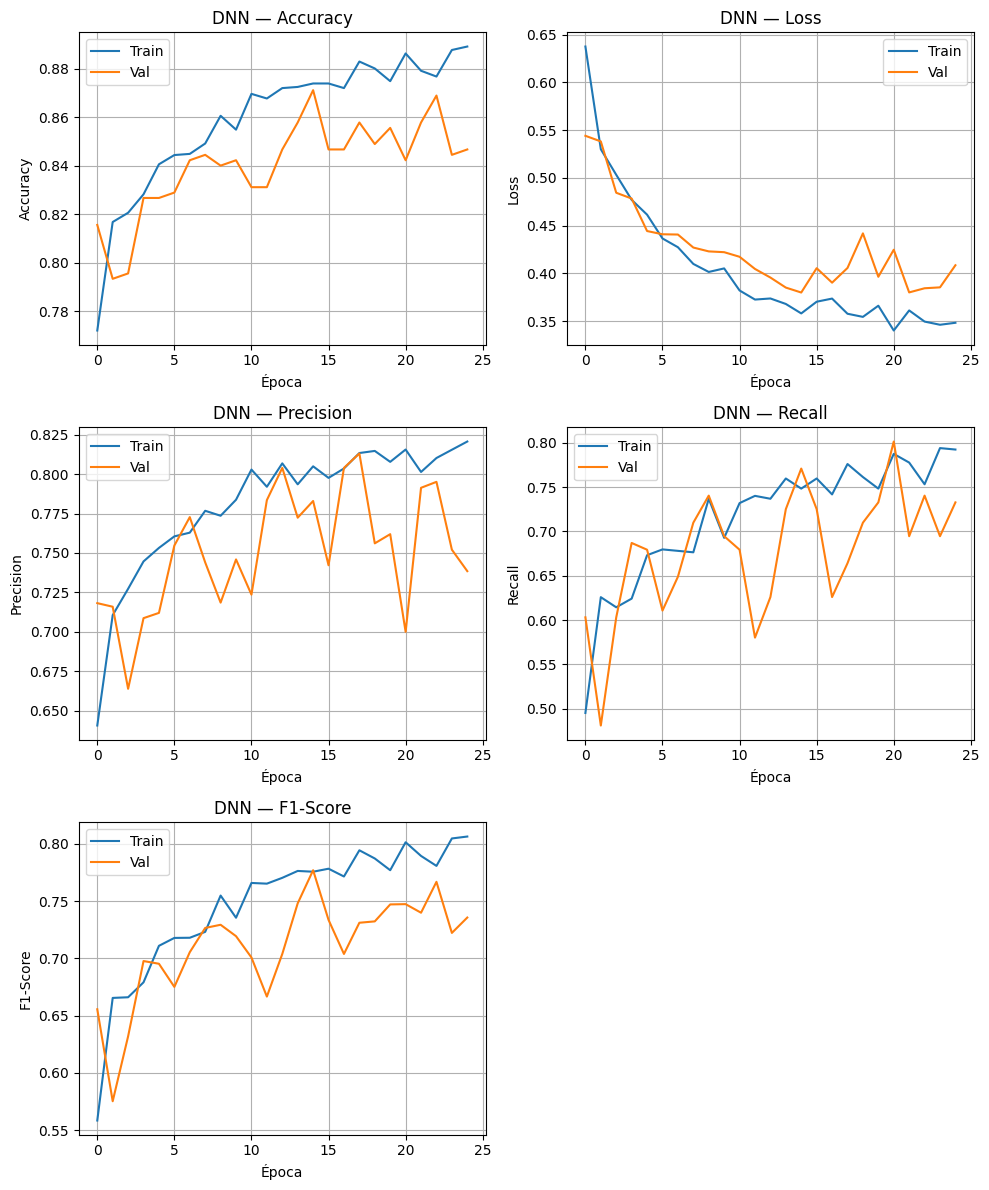

In [43]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

metricas = [
    ('accuracy',  'val_accuracy',  'Accuracy'),
    ('loss',      'val_loss',      'Loss'),
    ('precision', 'val_precision', 'Precision'),
    ('recall',    'val_recall',    'Recall'),
    ('f1_score',  'val_f1_score',  'F1-Score'),
]

for ax, (train_key, val_key, titulo) in zip(axes.flatten(), metricas):
    ax.plot(history.history[train_key], label='Train')
    ax.plot(history.history[val_key],   label='Val')
    ax.set_title(f'DNN — {titulo}')
    ax.set_xlabel('Época')
    ax.set_ylabel(titulo)
    ax.legend()
    ax.grid(True)

axes.flatten()[-1].set_visible(False)

plt.tight_layout()
plt.show()

## Veredicto...

## Paso 6: Evaluación Final del Mejor Modelo

# Paso 7